# Module 3.3 — Mesh Generation

**Why meshing is 40–60% of the engineer's time in a real CFD project:**
A perfect solver on a bad mesh gives wrong answers. A decent solver on a well-designed mesh gives good answers. In industrial CFD, mesh generation is often the bottleneck — not the solver. Understanding what makes a mesh good or bad is not optional.

**The map analogy:**
A mesh is a map of the fluid domain. Just as a good map must cover every part of the territory without gaps, overlaps, or distortion, a good mesh must cover every part of the fluid domain with non-overlapping cells of reasonable shape. The challenge: physical domains are curved, irregular, and multi-scale.

**Roadmap:**
1. Structured vs. unstructured meshes — advantages and trade-offs
2. Mesh quality metrics — skewness, aspect ratio, orthogonality, and why each matters
3. Near-wall meshing — $y^+$ estimation and boundary layer grading
4. Mesh convergence study — the only way to know if your mesh is fine enough
5. Common mesh topologies — O-grid, C-grid, H-grid
6. Python: generating structured meshes and measuring quality

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

## 1. Structured vs. Unstructured Meshes

### Structured mesh

Grid points arranged in a regular $i$-$j$ index space. Every interior point has exactly the same number of neighbours.

```
j=3  +----+----+----+----+----+
     |    |    |    |    |    |
j=2  +----+----+----+----+----+    neighbours of cell (i,j):
     |    | (i,j)   |    |    |    left:  (i-1, j)
j=1  +----+----+----+----+----+    right: (i+1, j)
     |    |    |    |    |    |    above: (i,   j+1)
j=0  +----+----+----+----+----+    below: (i,   j-1)
    i=0  i=1  i=2  i=3  i=4  i=5
```

**Pros:** fast indexing (`u[i,j]`), cache-friendly, high-order schemes easy, multigrid straightforward.

**Cons:** hard to fit complex geometry — topology must follow shape.

---

### Unstructured mesh

Cells of arbitrary shape connected via an explicit connectivity table. No regular index — each cell stores a list of its neighbours.

```
     *-----------*
    / \  cell 2 / \
   / 1 \       /   \     connectivity table:
  *-----*-----*-----*     cell 0: nodes [3, 1, 5]
   \    |    /     /      cell 1: nodes [0, 3, 2]
    \ 0 | 3 /     /       cell 2: nodes [3, 4, 1]
     *--*--*-----*        (no fixed i-j — look up each time)
```

**Pros:** fits ANY geometry automatically, easy local refinement.

**Cons:** slower (random memory access), harder high-order schemes.

---

### Hybrid mesh — best of both

Structured prism layers near walls (for $y^+$ control) + unstructured cells in the bulk (for geometry flexibility).

```
y=H  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~  free stream
      \  /\  /\  /\  /\  /\  /\  /\
       \/  \/  \/  \/  \/  \/  \/  \    unstructured bulk
       /\  /\  /\  /\  /\  /\  /\  /
      /  \/  \/  \/  \/  \/  \/  \/
     ·  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·   <- transition
     |    |    |    |    |    |    |  |
     |    |    |    |    |    |    |  |   structured prism
     |    |    |    |    |    |    |  |   layers  (y+ control)
y=0  ══════════════════════════════════  WALL  (no-slip)
```

| Property | Structured | Unstructured | Hybrid |
|----------|-----------|-------------|-------|
| Geometry fit | Hard | Easy | Easy |
| Near-wall accuracy | Good | Needs care | Best |
| Speed | Fast | Slower | Moderate |
| Industry use | Simple shapes | Complex geometry | Most CFD projects |

## 2. Mesh Quality Metrics

### 2a. Skewness — shape deviation from ideal

How far does a cell deviate from the ideal shape (equilateral triangle or square)?

$$\text{Skewness} = \frac{\theta_{\max} - \theta_{\text{ideal}}}{180° - \theta_{\text{ideal}}}$$

where $\theta_{\text{ideal}} = 60°$ for triangles, $90°$ for quads.

- $0$: perfect equilateral cell
- $> 0.85$: problematic — interpolation error grows, solver may diverge
- $\to 1$: degenerate (flat, zero-volume cell — guaranteed divergence)

---

### 2b. Aspect Ratio — elongation

$$AR = \frac{\text{longest edge}}{\text{shortest edge}}$$

- $AR = 1$: perfect square / equilateral — best accuracy
- $AR \gg 1$: acceptable **only** when the long axis aligns with the flow (gradients are small there)

**Example:** A boundary layer at $Re = 10^6$ is 1 mm thick on a 1 m plate $\Rightarrow AR \sim 1000$ in the streamwise direction. This is fine because $\partial u / \partial x \approx 0$ there. High $AR$ **across** the flow is dangerous.

**Practical guideline:** $AR < 100$ in boundary layers (aligned), $AR < 5$ in bulk flow.

---

### 2c. Non-orthogonality — angle between face normal and cell-centre vector

$$\phi_{\text{non-orth}} = \angle(\hat{n}_{\text{face}},\ \mathbf{d}_{\text{cells}})$$

For FVM, the diffusion flux is computed as $\Gamma(\phi_N - \phi_P)/|\mathbf{d}|$. This assumes $\hat{n}$ is parallel to $\mathbf{d}$. Non-orthogonality introduces a correction:

$$F_{\text{total}} = F_{\text{orthogonal}} + F_{\text{non-orthogonal correction}}$$

Non-orthogonality $> 70°$: the correction dominates — solver diverges or requires very aggressive under-relaxation. OpenFOAM warns at $> 70°$.

---

### 2d. Expansion Ratio — cell-size growth rate

$$r = \frac{\Delta y_{i+1}}{\Delta y_i}$$

Controls how smoothly the mesh transitions from fine (near wall) to coarse (bulk).

- $r = 1$: uniform (no stretching)
- $r = 1.05$ to $1.2$: good practice — gradual transition
- $r > 1.5$: too abrupt — truncation error spikes at the interface

**Rule:** $r < 1.2$ everywhere in the boundary layer. Never let adjacent cells differ by more than 20%.

---

### Summary of quality targets

| Metric | Excellent | Acceptable | Problematic |
|--------|-----------|-----------|-------------|
| Skewness | $< 0.25$ | $< 0.85$ | $> 0.85$ |
| Aspect ratio (bulk) | $< 2$ | $< 5$ | $> 20$ |
| Non-orthogonality | $< 20°$ | $< 70°$ | $> 70°$ |
| Expansion ratio | $< 1.1$ | $< 1.2$ | $> 1.5$ |
| $y^+$ (resolved BL) | $< 1$ | $1$–$5$ | $5$–$30$ |
| $y^+$ (wall functions) | $30$–$60$ | $60$–$100$ | $> 200$ |

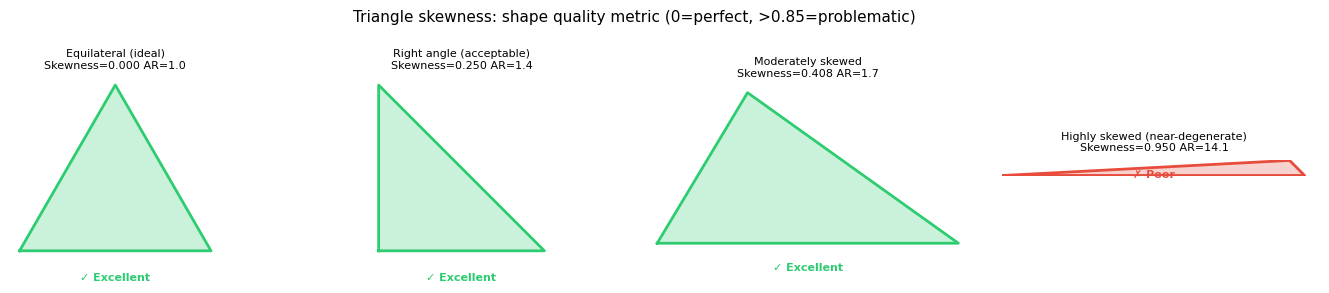

In [38]:
# ── Mesh quality metrics: skewness of triangles ───────────────────────────────

def triangle_quality(p1, p2, p3):
    """Compute skewness and aspect ratio of a triangle."""
    # Side lengths
    a = np.linalg.norm(p2 - p3)
    b = np.linalg.norm(p1 - p3)
    c = np.linalg.norm(p1 - p2)
    # Angles via law of cosines
    cos_A = np.clip((b**2 + c**2 - a**2) / (2*b*c + 1e-12), -1, 1)
    cos_B = np.clip((a**2 + c**2 - b**2) / (2*a*c + 1e-12), -1, 1)
    cos_C = np.clip((a**2 + b**2 - c**2) / (2*a*b + 1e-12), -1, 1)
    angles = np.degrees([np.arccos(cos_A), np.arccos(cos_B), np.arccos(cos_C)])
    theta_max = angles.max()
    theta_min = angles.min()
    eq = 60.0  # equilateral = 60°
    skewness = max((theta_max - eq)/(180-eq), (eq - theta_min)/eq)
    ar = max(a, b, c) / min(a, b, c)
    return skewness, ar, angles

# Test cases
triangles = [
    ('Equilateral (ideal)',
     np.array([0.0,0.0]), np.array([1.0,0.0]), np.array([0.5,0.866])),
    ('Right angle (acceptable)',
     np.array([0.0,0.0]), np.array([1.0,0.0]), np.array([0.0,1.0])),
    ('Moderately skewed',
     np.array([0.0,0.0]), np.array([1.0,0.0]), np.array([0.3,0.5])),
    ('Highly skewed (near-degenerate)',
     np.array([0.0,0.0]), np.array([1.0,0.0]), np.array([0.95,0.05])),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for ax, (name, p1, p2, p3) in zip(axes, triangles):
    sk, ar, angs = triangle_quality(p1, p2, p3)
    pts = np.array([p1, p2, p3, p1])
    color = '#2ecc71' if sk < 0.5 else '#f39c12' if sk < 0.8 else '#e74c3c'
    ax.fill(pts[:,0], pts[:,1], alpha=0.25, color=color)
    ax.plot(pts[:,0], pts[:,1], '-', color=color, lw=2)
    ax.set_title(f'{name}\nSkewness={sk:.3f} AR={ar:.1f}', fontsize=8)
    ax.set_aspect('equal'); ax.axis('off')
    # Colour legend
    label = '✓ Excellent' if sk < 0.5 else '⚠ Acceptable' if sk < 0.85 else '✗ Poor'
    ax.text(0.5, -0.12, label, ha='center', transform=ax.transAxes,
            fontsize=8, color=color, fontweight='bold')

plt.suptitle('Triangle skewness: shape quality metric (0=perfect, >0.85=problematic)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 3. Near-Wall Meshing — $y^+$ Estimation

### The chicken-and-egg problem

You need $y^+$ to know if your mesh resolves the sublayer. But $y^+ = y_1 u_\tau / \nu$ requires $u_\tau$ — which you only know **after** running the simulation.

**Solution:** estimate $u_\tau$ before running using empirical skin-friction correlations.

---

### Empirical correlations

**Flat plate (external aerodynamics) — Prandtl power law:**

$$C_f \approx 0.027\, Re_L^{-1/7}$$

**Pipe / channel (internal flow) — Blasius:**

$$C_f \approx 0.079\, Re_D^{-1/4} \qquad (Re_D < 10^5)$$

---

### Step-by-step workflow

$$\boxed{\text{Step 1: } Re = \frac{UL}{\nu}}$$

$$\text{Step 2: } C_f \text{ from correlation above}$$

$$\text{Step 3: } \tau_w = \frac{1}{2}\,\rho\,U^2\,C_f$$

$$\text{Step 4: } u_\tau = \sqrt{\frac{\tau_w}{\rho}}$$

$$\boxed{\text{Step 5: } y_1 = \frac{y^+_{\text{target}}\,\nu}{u_\tau}}$$

$$\text{Step 6 (check): } Re_\tau = \frac{u_\tau H}{\nu} = y^+_{\text{max}}$$

---

### Physical insight: why $y_1$ is tiny at high $Re$

From the correlations: $u_\tau \propto U \cdot Re^{-1/14}$ (flat plate). So $y_1 = y^+\nu/u_\tau \propto Re^{-6/7}$.

As Reynolds number doubles, the required first-cell height roughly **halves**. This is why meshing high-$Re$ flows (aircraft, ships) is so expensive — you need $y_1 \sim 1\,\mu\text{m}$ at cruise conditions.

### Grid stretching strategies

Once $y_1$ is known, build the rest of the boundary-layer mesh by stretching away from the wall.

**Geometric (exponential):** each cell is $r$ times thicker than the previous:

$$\Delta y_i = \Delta y_0 \cdot r^{i}, \qquad \Delta y_0 = H\,\frac{1-r}{1-r^{N-1}}$$

**Tanh stretching:** smooth clustering controlled by a single parameter $s$:

$$y_i = H\left(1 - \frac{\tanh\!\left[s(1-\xi_i)\right]}{\tanh s}\right), \qquad \xi_i = \frac{i}{N-1}$$

- Small $s$: nearly uniform
- Large $s$: strong clustering near $y = 0$

Case                                          Re  y+ target    y_1 (mm)      u_tau
-------------------------------------------------------------------------------------
Aircraft wing  10m, 250m/s, air          1.7e+08          1      0.0020     7.5133
Aircraft wing  10m, 250m/s, air          1.7e+08         50      0.0998     7.5133
Car  4m, 30m/s, air                      8.0e+06          1      0.0134     1.1200
Car  4m, 30m/s, air                      8.0e+06         50      0.6697     1.1200
Pipe D=0.1m, 3m/s, water                 3.0e+05          1      0.0081     0.1232
Pipe D=0.1m, 3m/s, water                 3.0e+05         30      0.2434     0.1232


<>:70: SyntaxWarning: invalid escape sequence '\,'
<>:70: SyntaxWarning: invalid escape sequence '\,'
/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_9849/657946215.py:70: SyntaxWarning: invalid escape sequence '\,'
  axes[1].set_title(f'Graded BL mesh: $y_1={rp["y1"]*1e6:.1f}\,\mu m$, ratio=1.15')


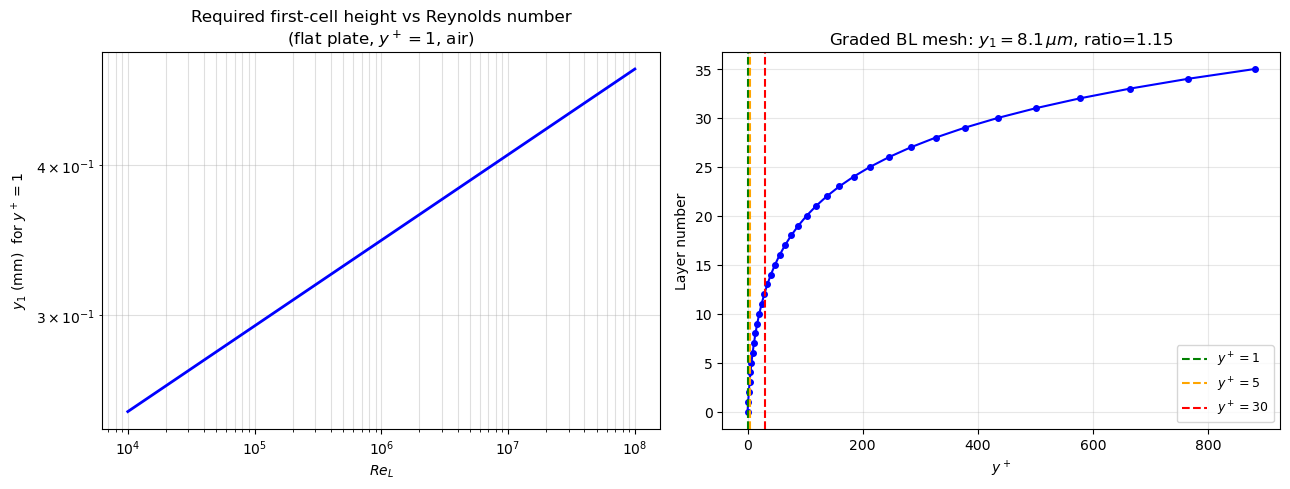

In [39]:
# y+ calculator: first cell height for turbulent BL meshing
# Flat-plate:  Cf = 0.027 * Re^(-1/7)   (Prandtl power law)
# Pipe/channel: Cf = 0.079 * Re^(-1/4)   (Blasius)

def estimate_y1(U, L, nu, rho=1.0, yplus_target=1.0, geometry='flat_plate'):
    Re    = U * L / nu
    Cf    = 0.027*Re**(-1/7) if geometry=='flat_plate' else 0.079*Re**(-0.25)
    tau_w = 0.5 * rho * U**2 * Cf
    u_tau = np.sqrt(tau_w / rho)
    y1    = yplus_target * nu / u_tau
    return dict(Re=Re, Cf=Cf, tau_w=tau_w, u_tau=u_tau, y1=y1,
                Re_tau=u_tau*L/nu)

# Geometric (exponential) stretching
def graded_mesh(y_first, H, n_layers, ratio):
    y = [0.0]; dy = y_first
    for _ in range(n_layers):
        y.append(y[-1] + dy); dy *= ratio
    return np.array(y)

# Tanh stretching
def tanh_grid(N, H, s):
    xi = np.linspace(0, 1, N)
    return H * (1 - np.tanh(s*(1-xi)) / np.tanh(s))

# Step-by-step workflow
# Step 1: Re  = U * L / nu
# Step 2: Cf  from empirical correlation
# Step 3: tau_w = 0.5 * rho * U^2 * Cf
# Step 4: u_tau = sqrt(tau_w / rho)
# Step 5: y_1   = y+_target * nu / u_tau
# Step 6: Re_tau = u_tau * H / nu   (verify: matches y+_max)

cases = [
    ('Aircraft wing  10m, 250m/s, air', 250, 10.0, 1.5e-5, 0.4,   1,  'flat_plate'),
    ('Aircraft wing  10m, 250m/s, air', 250, 10.0, 1.5e-5, 0.4,  50,  'flat_plate'),
    ('Car  4m, 30m/s, air',              30,  4.0, 1.5e-5, 1.2,   1,  'flat_plate'),
    ('Car  4m, 30m/s, air',              30,  4.0, 1.5e-5, 1.2,  50,  'flat_plate'),
    ('Pipe D=0.1m, 3m/s, water',          3,  0.1, 1.0e-6, 1000,  1,  'pipe'),
    ('Pipe D=0.1m, 3m/s, water',          3,  0.1, 1.0e-6, 1000, 30,  'pipe'),
]
print(f'{"Case":<38} {"Re":>9} {"y+ target":>10} {"y_1 (mm)":>11} {"u_tau":>10}')
print('-'*85)
for name,U,L,nu,rho,yp,geom in cases:
    r = estimate_y1(U,L,nu,rho,yp,geom)
    print(f'{name:<38} {r["Re"]:>9.1e} {yp:>10.0f} {r["y1"]*1000:>11.4f} {r["u_tau"]:>10.4f}')

# Sensitivity: y_1 vs Re_L
Re_vals = np.logspace(4, 8, 200)
y1_mm   = [estimate_y1(1.0, Re*1.5e-5, 1.5e-5, yplus_target=1.0)['y1']*1000
           for Re in Re_vals]

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].loglog(Re_vals, y1_mm, 'b-', lw=2)
axes[0].set_xlabel('$Re_L$'); axes[0].set_ylabel('$y_1$ (mm)  for $y^+ = 1$')
axes[0].set_title('Required first-cell height vs Reynolds number\n(flat plate, $y^+=1$, air)')
axes[0].grid(True, which='both', alpha=0.4)

# Graded mesh y+ distribution
nu_p = 1e-6
rp   = estimate_y1(3.0, 0.1, nu_p, 1000, 1.0, 'pipe')
y_mesh = graded_mesh(rp['y1'], 0.05, 35, 1.15)
yp_mesh = y_mesh * rp['u_tau'] / nu_p
axes[1].plot(yp_mesh, np.arange(len(yp_mesh)), 'b-o', ms=4)
axes[1].axvline(1,  color='green',  ls='--', lw=1.5, label='$y^+=1$')
axes[1].axvline(5,  color='orange', ls='--', lw=1.5, label='$y^+=5$')
axes[1].axvline(30, color='red',    ls='--', lw=1.5, label='$y^+=30$')
axes[1].set_xlabel('$y^+$'); axes[1].set_ylabel('Layer number')
axes[1].set_title(f'Graded BL mesh: $y_1={rp["y1"]*1e6:.1f}\,\mu m$, ratio=1.15')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

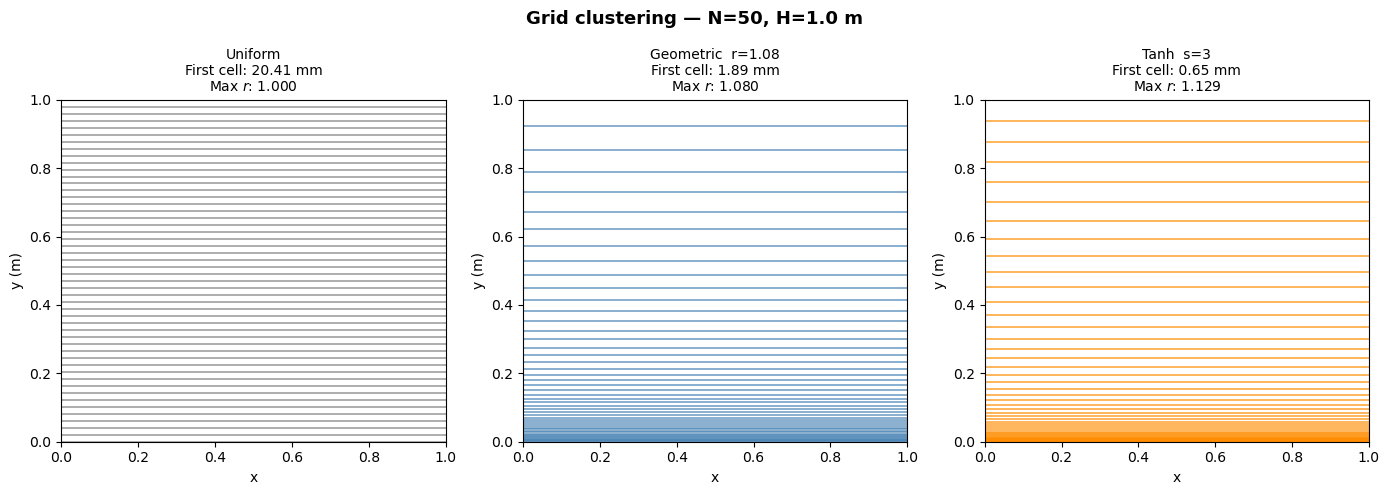

 Layer   Uniform r    Geometric r    Tanh r
     1      1.0000         1.0800    1.1295
     2      1.0000         1.0800    1.1294
     3      1.0000         1.0800    1.1293
     4      1.0000         1.0800    1.1291
     5      1.0000         1.0800    1.1290
     6      1.0000         1.0800    1.1288
     7      1.0000         1.0800    1.1287
     8      1.0000         1.0800    1.1284
     9      1.0000         1.0800    1.1282
    10      1.0000         1.0800    1.1279


In [40]:
# Grid clustering comparison: Uniform vs Geometric vs Tanh
N = 50; H = 1.0
dy0      = H*(1-1.08)/(1-1.08**(N-1))
y_uniform = np.linspace(0, H, N)
y_geom    = graded_mesh(dy0, H, N-1, 1.08)[:N]
y_tanh    = tanh_grid(N, H, s=3.0)

def expansion_ratio(y):
    dy = np.diff(y)
    return dy[1:] / dy[:-1]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, y, label, color in zip(
        axes,
        [y_uniform, y_geom, y_tanh],
        ['Uniform', 'Geometric  r=1.08', 'Tanh  s=3'],
        ['gray', 'steelblue', 'darkorange']):
    for yi in y:
        ax.axhline(yi, color=color, lw=1.2, alpha=0.75)
    er = expansion_ratio(y)
    ax.set_title(
        f'{label}\nFirst cell: {y[1]*1000:.2f} mm\nMax $r$: {er.max():.3f}',
        fontsize=10)
    ax.set_xlim(0,1); ax.set_ylim(0, H)
    ax.set_xlabel('x'); ax.set_ylabel('y (m)')
plt.suptitle(f'Grid clustering — N={N}, H={H} m', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'{"Layer":>6}  {"Uniform r":>10}  {"Geometric r":>13}  {"Tanh r":>8}')
for i in range(min(10, N-2)):
    print(f'{i+1:>6}  {expansion_ratio(y_uniform)[i]:>10.4f}  '
          f'{expansion_ratio(y_geom)[i]:>13.4f}  {expansion_ratio(y_tanh)[i]:>8.4f}')

## 4. Mesh Convergence Study — The Only Reliable Accuracy Check

### Why you must always do this

A single mesh gives you one answer. You don't know if that answer is converged to the
true solution or still changing with refinement. Only by comparing three or more grids can you:
1. Confirm that the solution is converging (error decreasing with refinement)
2. Estimate the observed order of convergence (should match scheme order)
3. Determine the mesh-independent solution

### Richardson extrapolation

If you have solutions on three grids (coarse $\phi_c$, medium $\phi_m$, fine $\phi_f$) with spacing ratio $r$:

$$\phi_{\text{exact}} \approx \phi_f + \frac{\phi_f - \phi_m}{r^p - 1}$$

where the **observed order of convergence** $p$ is:

$$p = \frac{\ln\!\left[(\phi_m - \phi_c)/(\phi_f - \phi_m)\right]}{\ln r}$$

**Practical rule:** if the quantity of interest changes by less than 1% between medium and fine grid, the medium grid is mesh-independent.

---

## 5. Common Mesh Topologies for External Flow

| Topology | Description | Best for |
|----------|-------------|----------|
| **O-grid** | Concentric rings around body | Cylinder, sphere |
| **C-grid** | Wraps around leading edge, cuts behind | Airfoils |
| **H-grid** | Rectangular, body inside | Far-field, Cartesian IB |
| **Hybrid C+H** | C-grid near wing + H far-field | Practical aircraft |

---

## 6. Geometric vs Tanh Stretching — Comparison

**Geometric:** $\Delta y_i = \Delta y_0 \cdot r^{i}$

**Tanh:** $y_i = H\!\left(1 - \dfrac{\tanh[s(1-\xi_i)]}{\tanh s}\right)$, $\quad \xi_i = i/(N-1)$

| Method | First-cell control | Growth profile | Typical use |
|--------|--------------------|----------------|-------------|
| Geometric | Explicit via $r$ and $\Delta y_0$ | Accelerates away from wall | BL, pipe |
| Tanh | Tune $s$ | Smooth, plateaus at centre | Channel, DNS |

---

## Summary

| Concept | Key rule |
|---------|----------|
| Skewness | $< 0.85$ |
| Aspect ratio | High in BL (aligned ok), low in bulk |
| Non-orthogonality | $< 70°$ |
| Expansion ratio | $< 1.2$ per layer |
| $y^+$ | $< 1$ resolved BL; $30$–$100$ wall functions |
| Convergence study | Always: coarse / medium / fine + Richardson extrapolation |

## 7. Exercise — Design a Mesh for the Turbulent Channel

Use what you have learned to design a proper mesh for the turbulent channel from Module 3.18.

**Given:**
- Channel half-height: $H = 0.05\,\text{m}$
- Full channel height (gap): $2H = 0.10\,\text{m}$
- Hydraulic diameter: $D_h = 2 \times 2H = 0.20\,\text{m}$  ← use this as `L`
- Bulk velocity: $U = 10\,\text{m/s}$
- Kinematic viscosity: $\nu = 1.5 \times 10^{-5}\,\text{m}^2/\text{s}$ (air)
- Density: $\rho = 1.2\,\text{kg/m}^3$ (air)
- Target: $y^+ = 1$ at the first cell

**Why $L = D_h$?**

The Blasius correlation $C_f = 0.079\,Re^{-1/4}$ was calibrated for pipe flow where $Re = U D_h / \nu$. For parallel plates with gap $2H$:

$$D_h = 2 \times \text{gap} = 2 \times 2H = 4H$$

---

**Tasks:**
1. Call `estimate_y1(U=10, L=0.20, nu=1.5e-5, rho=1.2, yplus_target=1, geometry='pipe')` to find $y_1$
2. Build the grid: `graded_mesh(y1, H=0.05, n_layers=60, ratio=1.15)`
3. Compute $y^+$ at each node using the $u_\tau$ from `estimate_y1` and check the first cell lands at $y^+ \approx 1$
4. Plot the $y^+$ distribution (layer number vs $y^+$)
5. Print the expansion ratio — is it below 1.2 everywhere?

**Predict first:** With geometric clustering ($r=1.15$, $N=60$), will you need more or fewer total cells than the uniform $N=500$ from Module 3.18 to hit $y^+ \approx 1$? Why?